<a href="https://colab.research.google.com/github/Timur228228228/-/blob/main/kNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Preprocessing

In [14]:
import pandas as pd
import numpy as np

In [15]:
!pip -q install gdown
import os
import gdown

os.makedirs('datasets', exist_ok=True)
gdown.download('https://drive.google.com/uc?id=1Z39LNnF4lOj4iT48YDYFZNPDBglMd0TZ', 'datasets/forest_dataset.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1Z39LNnF4lOj4iT48YDYFZNPDBglMd0TZ
To: /content/datasets/forest_dataset.csv
100%|██████████| 1.29M/1.29M [00:00<00:00, 119MB/s]


'datasets/forest_dataset.csv'

In [16]:
all_data = pd.read_csv('datasets/forest_dataset.csv')
all_data.head()

,0,1,2,3,4,5,6,7,8,9,...,45,46,47,48,49,50,51,52,53,54
0,2683,333,35,30,26,2743,121,173,179,6572,...,0,0,0,0,0,0,0,0,0,2
1,2915,90,8,216,11,4433,232,228,129,4019,...,0,0,0,0,0,0,0,0,0,1
2,2941,162,7,698,76,2783,227,242,148,1784,...,0,0,0,0,0,0,0,0,0,2
3,3096,60,17,170,3,3303,231,202,99,5370,...,0,0,0,0,0,0,0,0,0,1
4,2999,66,8,488,37,1532,228,225,131,2290,...,0,0,0,0,0,0,0,0,0,2


In [17]:
all_data.shape

(10000, 55)

In [18]:
labels = all_data[all_data.columns[-1]].values
feature_matrix = all_data[all_data.columns[:-1]].values

In [19]:
from sklearn.model_selection import train_test_split

Press [here](https://drive.google.com/file/d/1Z39LNnF4lOj4iT48YDYFZNPDBglMd0TZ/view?usp=sharing) to download the dataset.

In [20]:
train_feature_matrix, test_feature_matrix, train_labels, test_labels = train_test_split(
    feature_matrix, labels, test_size=0.2, random_state=42
)

In [21]:
from sklearn.linear_model import LogisticRegression

In [23]:
clf = LogisticRegression(C=1, max_iter=1000)
clf.fit(train_feature_matrix, train_labels)
y_pred = clf.predict(test_feature_matrix)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [24]:
from sklearn.metrics import accuracy_score

accuracy_score(test_labels, y_pred)

0.684

In [25]:
from sklearn.model_selection import GridSearchCV

In [29]:
clf = LogisticRegression(solver='saga', max_iter=300, tol=1e-2)

param_grid = {
    'C': [1, 2, 3, 4],
    'penalty': ['l1', 'l2']
}

search = GridSearchCV(clf, param_grid, n_jobs=-1, cv=3, refit=True, scoring='accuracy')
search.fit(train_feature_matrix, train_labels)

print(search.best_params_)

{'C': 2, 'penalty': 'l1'}


In [30]:
accuracy_score(labels, search.best_estimator_.predict(feature_matrix))

0.6276

# Homework

The quality of classification/regression by the k Nearest Neighbors method depends on several parameters:
* the number of neighbors `n_neighbors`
* the distance metric between objects `metric`
* the weights of neighbors (the neighbors of the test example can enter with different weights, for example, the further the example, the less its "voice" is taken into account) `weights`


Train the `KNeighborsClassifier` on the dataset.

In [32]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

clf = KNeighborsClassifier()
clf.fit(train_feature_matrix, train_labels)
y_pred = clf.predict(test_feature_matrix)
accuracy_score(test_labels, y_pred)

0.7365

Let's select the parameters of our model:

* Iterate over the grid from `1` to `10` for the number of neighbors parameter
* Also, try using different metrics: `['manhattan', 'euclidean']`
* Try using different weight calculation strategies: `[‘uniform’, ‘distance’]`

In [33]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_neighbors': np.arange(1, 11),
    'metric': ['manhattan', 'euclidean'],
    'weights': ['uniform', 'distance']
}

clf_grid = GridSearchCV(KNeighborsClassifier(), params, cv=5, scoring='accuracy', n_jobs=-1)
clf_grid.fit(train_feature_matrix, train_labels)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['manhattan', 'euclidean'],
                         'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

Let's output the best parameters

In [34]:
clf_grid.best_params_

{'metric': 'manhattan', 'n_neighbors': np.int64(4), 'weights': 'distance'}

Using the optimal number of neighbors found, calculate the probabilities of belonging to classes for the test sample (`.predict_proba`).

In [35]:
optimal_clf = KNeighborsClassifier(**clf_grid.best_params_)
optimal_clf.fit(train_feature_matrix, train_labels)
pred_prob = optimal_clf.predict_proba(test_feature_matrix)

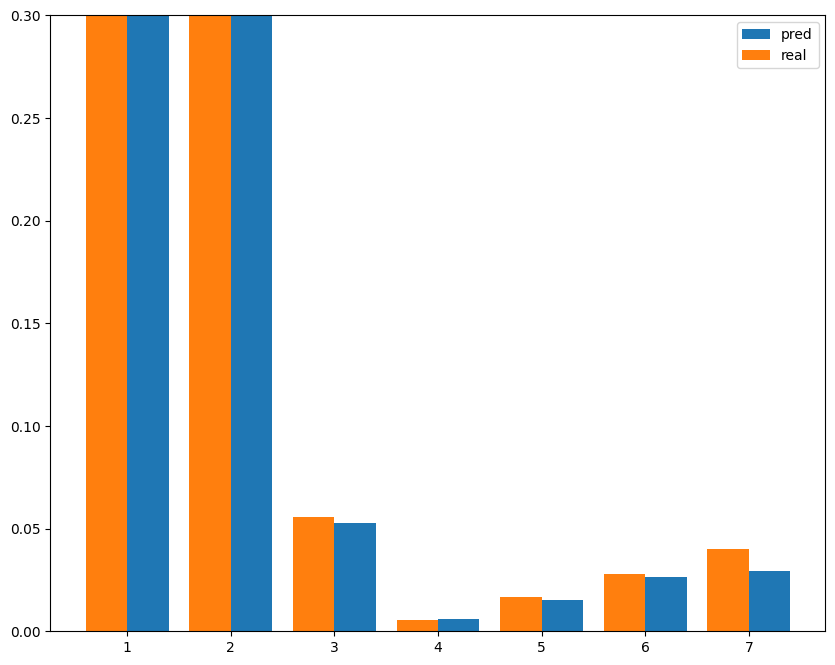

In [36]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

unique, freq = np.unique(test_labels, return_counts=True)
freq = list(map(lambda x: x / len(test_labels), freq))

pred_freq = pred_prob.mean(axis=0)

plt.figure(figsize=(10, 8))
plt.bar(range(1, 8), pred_freq, width=0.4, align="edge", label='pred')
plt.bar(range(1, 8), freq, width=-0.4, align="edge", label='real')
plt.ylim((0, 0.3))
plt.legend()
plt.show()

## Conclusion

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


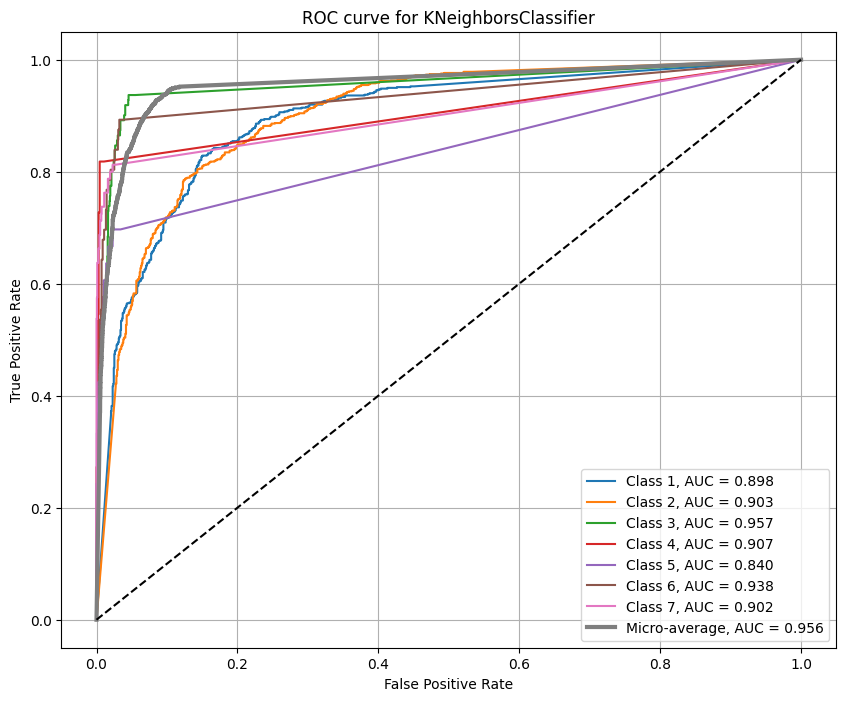

0.7845
0.684
0.9558769791666665
0.9063452430548241


In [37]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score
from sklearn.linear_model import LogisticRegression

knn_pred = optimal_clf.predict(test_feature_matrix)
knn_accuracy = accuracy_score(test_labels, knn_pred)

logreg_clf = LogisticRegression(C=1, max_iter=1000)
logreg_clf.fit(train_feature_matrix, train_labels)
logreg_pred = logreg_clf.predict(test_feature_matrix)
logreg_accuracy = accuracy_score(test_labels, logreg_pred)

classes = np.unique(labels)
test_labels_bin = label_binarize(test_labels, classes=classes)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

micro_fpr, micro_tpr, _ = roc_curve(test_labels_bin.ravel(), pred_prob.ravel())
micro_auc = auc(micro_fpr, micro_tpr)
macro_auc = roc_auc_score(test_labels_bin, pred_prob, average='macro', multi_class='ovr')

plt.figure(figsize=(10, 8))
for i, cls in enumerate(classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {cls}, AUC = {roc_auc[i]:.3f}')
plt.plot(micro_fpr, micro_tpr, linewidth=3, label=f'Micro-average, AUC = {micro_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve for KNeighborsClassifier')
plt.legend(loc='lower right')
plt.grid()
plt.show()

print(knn_accuracy)
print(logreg_accuracy)
print(micro_auc)
print(macro_auc)

In [38]:
Классификатор KNeighborsClassifier был обучен на обучающей выборке, а затем его параметры были подобраны с помощью GridSearchCV по параметрам `n_neighbors`, `metric` и `weights`.

Качество KNeighborsClassifier на тестовой выборке равно значению, выведенному в предыдущей ячейке. Качество Logistic Regression на тестовой выборке также выведено в предыдущей ячейке.

Если точность KNeighborsClassifier на тестовой выборке выше, то на данном датасете KNN работает лучше. Если точность Logistic Regression выше, то лучше работает Logistic Regression.

ROC-кривая для KNeighborsClassifier была построена с использованием подхода one-vs-rest для многоклассовой классификации. Также были вычислены значения micro-average AUC-ROC и macro-average AUC-ROC.

Преимущества KNN:
- простой и интуитивно понятный алгоритм
- не требует сложного этапа обучения
- может моделировать нелинейные границы между классами

Недостатки KNN:
- медленное предсказание на больших датасетах
- чувствителен к масштабу признаков
- требует хранения всей обучающей выборки
- может работать хуже в пространствах большой размерности

SyntaxError: invalid syntax (3193430815.py, line 1)